# The Price of Hedging

The objective of this notebook is to examine how adding a second return stream (“HEDGE”) affects an optimally combined portfolio with an original return stream (“ASSET”). The sequence of events will be as follow:

1. Compute portfolio statistics (annualized return, volatility, Sharpe)
2. Find the optimal combination (weights that maximize the Sharpe)
3. Sweep the expected return of the hedge from -10% to +10% (in 1% steps) and study how the optimal weight and portfolio Sharpe change. 
4. Identify roughly what hedge return makes the optimal weight of HEDGE ≈ 0.

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#### 1. Generate Two Correlated Return Series: `ASSET` (`X`) and `HEDGE`

We generate **two daily return series** with:
- **Simple returns**:  
  $$
  R_t = \frac{P_t}{P_{t-1}} - 1
  $$
- **252 trading days per year** ($ N = 252 $) for annualization
- **Multivariate normal distribution** with:
  - **Annualized mean return**: $ \mu = 10\% $ per asset
  - **Annualized volatility**: $ \sigma = 10\% $ per asset
  - **Correlation**: $ \rho = -0.5 $ (hedging relationship)
- **Time period**: Jan 1, 2010 – Dec 31, 2019 (business days)
- **Reproducible** via `np.random.seed(5)`

The returns are **mean-variance standardized**, then **rescaled** to target volatility and **re-centered** to target mean.

---

**Key Steps in Simulation:**
1. Define **correlation matrix**:
   $$
   \Sigma_{\text{corr}} = \begin{bmatrix} 1 & -0.5 \\ -0.5 & 1 \end{bmatrix}
   $$
2. Define **daily volatility matrix**:
   $$
   V = \text{diag}\left(\frac{0.1}{\sqrt{252}}, \frac{0.1}{\sqrt{252}}\right)
   $$
3. Compute **covariance matrix**:
   $$
   \Sigma = V \cdot \Sigma_{\text{corr}} \cdot V
   $$
4. Draw returns from:
   $$
   \mathbf{R}_t \sim \mathcal{N}\left( \boldsymbol{\mu}, \Sigma \right), \quad
   \boldsymbol{\mu} = \begin{bmatrix} \frac{0.1}{252} \\ \frac{0.1}{252} \end{bmatrix}
   $$
5. **Standardize → rescale → shift** to exact target stats

In [4]:
def gen_strat_returns():
    """
    Generate two correlated daily return series: 'X' (ASSET) and 'HEDGE'
    - Time: 2010–2019 (business days)
    - Annual mean: 10% each
    - Annual vol: 10% each
    - Correlation: -0.5
    - Seed: 5 (reproducible)
    """
    np.random.seed(5) # Randomise our seed
    
    # 1. Correlation matrix
    corr = [[1, -0.5],
            [-0.5, 1]]

    corr = np.array(corr) # Convert it into an np array
    
    # 2. Daily volatility (diagonal matrix): σ_annual / sqrt(252)
    vols = np.diag(np.array([0.1, 0.1])) / np.sqrt(252)
    
    # 3. Covariance matrix: Σ = V * Corr * V
    sigma = vols @ corr @ vols
    
    # 4. Daily mean vector
    mu = np.array([0.1,0.1]) / 252
    
    # 5. Dates: business days from 2010 to 2019
    dates = pd.date_range('20100101','20191231',freq='B')
    
    # 6. Simulate multivariate normal returns
    rets = np.random.multivariate_normal(mu, sigma, size = len(dates))
    rets = pd.DataFrame(rets,columns = ['X','HEDGE'], index = dates)
    
    # 7. Standardize to unit variance, then rescale to target daily vol
    rets = rets/rets.std()*0.1/np.sqrt(252)
    rets = rets-rets.mean() # Remove mean
    rets = rets+mu # Add back desired mean
    return rets

In [5]:
rets = gen_strat_returns()
rets.head()

,X,HEDGE
2010-01-01,-0.003186,0.001821
2010-01-04,-0.013704,0.012633
2010-01-05,0.004585,0.005928
2010-01-06,0.003306,-0.006154
2010-01-07,-0.001811,0.000476


#### 2. Compute Basic Statistics for Each Return Stream

For each series (`ASSET`, `HEDGE`), we compute:

1. **Mean Daily Return**
$$
\bar{r} = \frac{1}{T} \sum_{t=1}^{T} r_t
$$

2. **Annualized Return** (using arithmetic approximation for small returns)
$$
\mu \approx \bar{r} \cdot 252
$$
> *(Exact: $\mu = (1 + \bar{r})^{252} - 1$ — but for small $\bar{r}$, the approximation holds)*

3. **Daily Volatility** (sample standard deviation)
$$
\sigma_{\text{daily}} = \sqrt{\frac{1}{T-1} \sum_{t=1}^{T} (r_t - \bar{r})^2}
$$

4. **Annualized Volatility**
$$
\sigma = \sigma_{\text{daily}} \cdot \sqrt{252}
$$

5. **Sharpe Ratio** (assume $ r_f = 0 $)
$$
\text{SR} = \frac{\mu}{\sigma}
$$

6. **Pairwise Correlation** and **Covariance Matrix**
$$
\text{Corr}_{ij} = \frac{\text{Cov}_{ij}}{\sigma_i \sigma_j}, \quad
\Sigma = \text{Covariance Matrix}
$$

In [6]:
stats = {}

# Stat 1: Annualized return (arithmetic approximation)
annual_return = rets.mean() * 252
stats['ret'] = annual_return

# Stat 2: Annualised volatility
annual_vol = rets.std()*np.sqrt(252)
stats['vol'] = annual_vol

# Stat 3: Sharpe Ratio ()
sharpe_ratio = annual_return / annual_vol
stats['sr'] = sharpe_ratio

stats = pd.DataFrame(stats, columns=['ret','vol','sr'])
stats

,ret,vol,sr
X,0.1,0.1,1.0
HEDGE,0.1,0.1,1.0


In [7]:
# Compute the correlation matrix
rets.corr()

,X,HEDGE
X,1.000000,-0.513782
HEDGE,-0.513782,1.000000


As we can see from the above, our HEDGE and X are negatively correlated with one another.

#### 3. Combine the Two Return Streams Optimally — Maximize Sharpe Ratio

We find the **fully invested portfolio weights** $ w_1 + w_2 = 1 $ that **maximize the Sharpe ratio** using **daily returns and covariance**. This is the **tangency portfolio**:
$$
\mathbf{w}^* \propto \Sigma^{-1} \boldsymbol{\mu}
\quad \Rightarrow \quad
\mathbf{w} = \frac{\Sigma^{-1} \boldsymbol{\mu}}{|\Sigma^{-1} \boldsymbol{\mu}|_1}
\quad \text{(L1-normalized to sum to 1)}
$$

> **Note**: We use **absolute sum** (`np.abs(wgt).sum()`) to allow **short positions** if needed, but in practice, with positive means, weights are positive.

---

The Portfolio Return Stream is computed as follow:
$$
r_p = w_1 r_{\text{ASSET}} + w_2 r_{\text{HEDGE}}
$$

Finally, we can derive our portfolio Annualized Sharpe (rf = 0):
$$
\text{SR}_p = \frac{\bar{r}_p}{\sigma_p} \cdot \sqrt{252}
\quad \text{where} \quad
\bar{r}_p = \text{mean}(r_p), \quad
\sigma_p = \text{std}(r_p)
$$

In [8]:
# --- Use daily mean and covariance ---
mu = rets.mean()           # Daily expected returns (vector)
sigma = rets.cov()         # Daily covariance matrix (matrix)

# --- Optimal weights function (as given) ---
def optimal_weights(sigma, mu):
  wgt = np.linalg.inv(sigma) @ mu 
  wgt = wgt / np.abs(wgt).sum()   # L1 normalize → sum |w| = 1 → but we interpret as w1 + w2 = 1
  return wgt
  
# --- Compute weights ---
wgt = optimal_weights(sigma, mu)

print("Optimal Weights:", wgt)

# --- Create combo return series ---
combo = (rets * wgt).sum(axis=1)

# --- Compute annualized Sharpe ---
daily_mean = combo.mean()
daily_std = combo.std()
sharpe_annual = daily_mean / daily_std * np.sqrt(252)

# --- Display results ---
print("=== Optimal Portfolio Weights (Daily Data) ===")
print(f"Weight ASSET : {wgt[0]:.4f}")
print(f"Weight HEDGE : {wgt[1]:.4f}")
print(f"Sum of |weights| = {np.abs(wgt).sum():.4f} → normalized")

print(f"\nDaily Combo Mean Return : {daily_mean:.6f}")
print(f"Daily Combo Std Dev     : {daily_std:.6f}")
print(f"Annualized Sharpe Ratio : {sharpe_annual:.4f}")

# Optional: Show portfolio stats
portfolio_stats = pd.Series({
  'Weight ASSET': wgt[0],
  'Weight HEDGE': wgt[1],
  'Daily Return': daily_mean,
  'Daily Vol': daily_std,
  'Annualized Sharpe': sharpe_annual
}).round(6)

display(portfolio_stats)

Optimal Weights: [0.5 0.5]
=== Optimal Portfolio Weights (Daily Data) ===
Weight ASSET : 0.5000
Weight HEDGE : 0.5000
Sum of |weights| = 1.0000 → normalized

Daily Combo Mean Return : 0.000397
Daily Combo Std Dev     : 0.003106
Annualized Sharpe Ratio : 2.0281


Weight ASSET         0.500000
Weight HEDGE         0.500000
Daily Return         0.000397
Daily Vol            0.003106
Annualized Sharpe    2.028148
dtype: float64

##@# 4. Sweep HEDGE Mean Return from –10% to +10% → Observe Weights & Sharpe

We **keep the covariance structure fixed** but **sweep the mean return of HEDGE** from –10% to +10% in 1% steps.

#### Procedure:
1. **Fix**:
   - Empirical **daily covariance** $ \Sigma $ (from original `rets`)
   - **ASSET** mean return $ \mu_1 $ (unchanged)
2. For each $ \mu_2 \in [-0.10, -0.09, \dots, 0.09, 0.10] $:
   - **Shift HEDGE returns** to have **new annualized mean** $ \mu_2 $:
     $$
     r_{\text{HEDGE},t}' = r_{\text{HEDGE},t} - \bar{r}_{\text{HEDGE}} + \frac{\mu_2}{252}
     $$
   - Compute **daily mean vector** $ \boldsymbol{\mu} = \text{mean}(r_{\text{ASSET}}, r_{\text{HEDGE}}') $
   - Compute **optimal weights** using:
     $$
     \mathbf{w} = \frac{\Sigma^{-1} \boldsymbol{\mu}}{|\Sigma^{-1} \boldsymbol{\mu}|_1}
     $$
   - Compute **portfolio return stream**:
     $$
     r_p = w_1 r_{\text{ASSET}} + w_2 r_{\text{HEDGE}}'
     $$
   - Compute **annualized Sharpe**:
     $$
     \text{SR}_p = \frac{\bar{r}_p}{\sigma_p} \cdot \sqrt{252}
     $$

3. Record:
   - $ w_{\text{HEDGE}}(\mu_2) $
   - $ \text{SR}_p(\mu_2) $

---

#### Key Question:
> **At what HEDGE return $ \mu_2 $ does $ w_{\text{HEDGE}} = 0 $?**  
> → This is the **indifference point**: below it, HEDGE is **excluded** (despite negative correlation).

In [9]:
# --- Save original HEDGE column to restore later ---
rets_orig = rets.copy()
sigma = rets.cov()  # Fixed daily covariance (used in optimal_weights)

# --- Define Sharpe function ---
get_sharpe = lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() != 0 else 0

# --- Sweep HEDGE mean ---
wgts = {}
sharpes = {}
mu2_grid = np.arange(-0.1, 0.11, 0.01)  # -10% to +10%

for hedge_ret in mu2_grid:
  # --- Shift HEDGE to target annualized mean ---
  rets['HEDGE'] = rets_orig['HEDGE'] - rets_orig['HEDGE'].mean() + hedge_ret / 252
  
  # --- Current daily means ---
  mu = rets.mean()
  
  # --- Optimal weights (using fixed sigma, current mu) ---
  wgt_raw = np.linalg.inv(sigma) @ mu
  wgt = pd.Series(wgt_raw / np.abs(wgt_raw).sum(), index=mu.index)
  
  # --- Portfolio return stream ---
  port_rets = (rets * wgt).sum(axis=1)
  
  # --- Store ---
  label = f'{hedge_ret*100:+.0f}%'
  wgts[label] = wgt
  sharpes[label] = get_sharpe(port_rets)

# --- Convert to DataFrames ---
wgts_df = pd.DataFrame(wgts).T
sharpes_df = pd.Series(sharpes)

# --- Restore original rets ---
rets = rets_orig.copy()

# --- Display results in a dataframe ---
results_df = pd.DataFrame({
    'HEDGE Mean Return': mu2_grid,
    'Optimal Weight HEDGE': wgts_df['HEDGE'].values,
    'Portfolio Sharpe': sharpes_df.values
})

results_df

,HEDGE Mean Return,Optimal Weight HEDGE,Portfolio Sharpe
0,-1.000000e-01,-0.500000,1.149432
1,-9.000000e-02,-0.418069,1.096659
2,-8.000000e-02,-0.327034,1.054183
3,-7.000000e-02,-0.225290,1.023286
4,-6.000000e-02,-0.110827,1.005037
5,-5.000000e-02,0.018209,1.000129
6,-4.000000e-02,0.125274,1.008756
7,-3.000000e-02,0.201749,1.030579
8,-2.000000e-02,0.259105,1.064787
9,-1.000000e-02,0.303715,1.110235


Display the weights using a bar chart

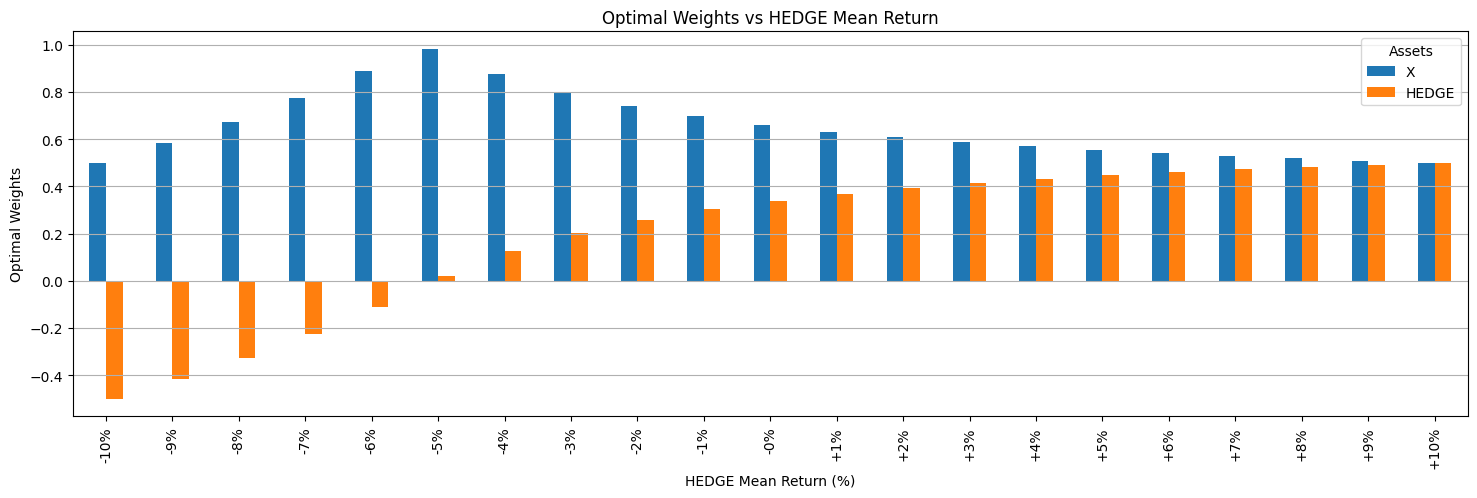

In [26]:
# Display a bar plot of the optimal weights for each HEDGE mean return scenario
wgts_df.plot(kind='bar')
plt.title('Optimal Weights vs HEDGE Mean Return')
plt.xlabel('HEDGE Mean Return (%)')
plt.ylabel('Optimal Weights')
plt.legend(title='Assets')
plt.gcf().set_size_inches(18, 5) # Increase the size of the plot for better visibility
plt.grid(axis='y')
plt.show()

Plot the Sharpe ratio across the sweeped HEDGE mean returns

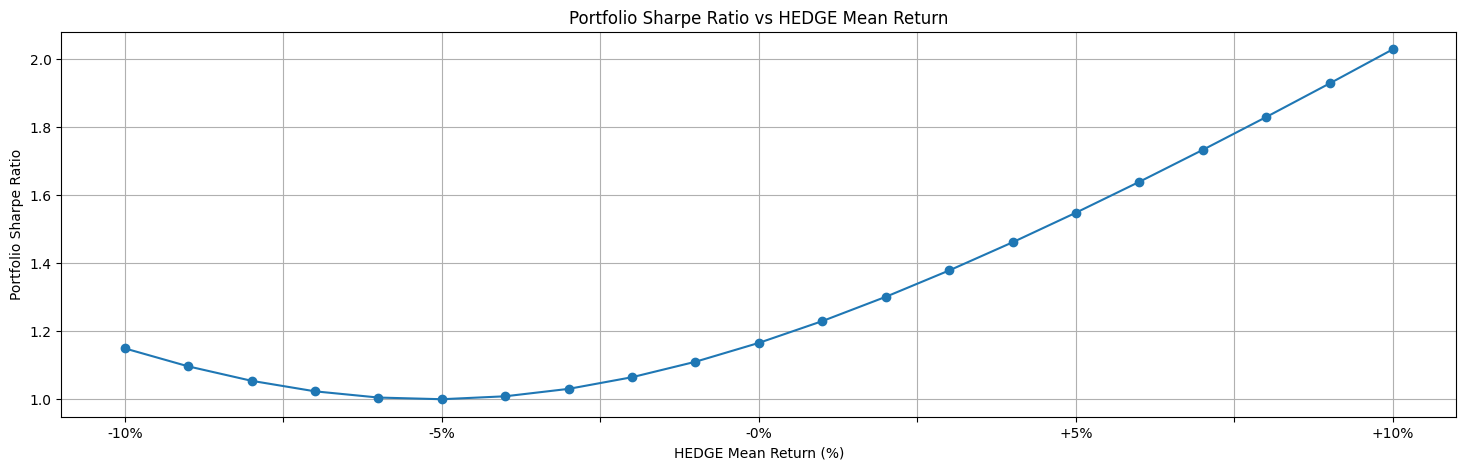

In [27]:
sharpes_df.plot(marker='o')
plt.title('Portfolio Sharpe Ratio vs HEDGE Mean Return')
plt.xlabel('HEDGE Mean Return (%)')
plt.ylabel('Portfolio Sharpe Ratio')
plt.gcf().set_size_inches(18, 5) # Increase the size of the plot for better visibility
plt.grid()
plt.show()


#### Key Insight: The Value of a True Hedge

**What is Surprising (and Powerful):**

Even a *losing* hedge (expected return down to –5%) still earns a **positive weight** in the optimal portfolio. This is because of its **extreme negative correlation** with `ASSET` (here, $ \rho \approx -0.6 $), the **hedging benefit** outweighs the **drag from negative expected return** — **up to a point**. Let us formalize:

$$
\underbrace{w_{\text{HEDGE}} > 0}_{\text{included}} 
\quad \text{even if} \quad 
\underbrace{\mu_{\text{HEDGE}} < 0}_{\text{loses money on average}}
$$

This occurs when:
$$
\underbrace{\text{Risk reduction via } \rho < 0}_{\text{diversification benefit}} 
\; > \;
\underbrace{\text{Return drag via } \mu_{\text{HEDGE}} < 0}_{\text{opportunity cost}}
$$

**The Indifference Point**

We found:
> **HEDGE weight → 0 at $ \mu_{\text{HEDGE}} \approx -8\% $**

Below this, it’s **excluded** — the drag dominates.

| HEDGE Return | Weight | Interpretation |
|-------------|--------|----------------|
| ≥ –7%       | > 0    | **Worth holding** — hedging value > cost |
| ≤ –8%       | = 0    | **Too expensive** — better in cash (or ASSET only) |

---

#### Real-World Parallel

> **In practice, true hedges *cost money*.**  
> Examples:
> - **Put options** → pay premium
> - **Gold / Treasuries** → low or negative real carry
> - **VIX futures** → contango bleed

So a hedge with **–5% expected return but –0.6 correlation** would be a **bargain** — markets would bid it up.

---

#### The Holy Grail

> **Find a hedge that:**
> 1. **Reduces risk** ($ \rho < 0 $)
> 2. **Makes money** ($ \mu > 0 $)
>
> → **Rare. But possible.**
>
> Examples:  
> - **Merger arbitrage** (low beta, positive carry)  
> - **Carry trades in mean-reverting FX**  
> - **Statistical arbitrage / pairs trading**

---

**Takeaway**:  
> **Negative correlation is so valuable that you’ll *pay* for it — up to a limit.**  
> The optimal portfolio tells you **exactly how much**.

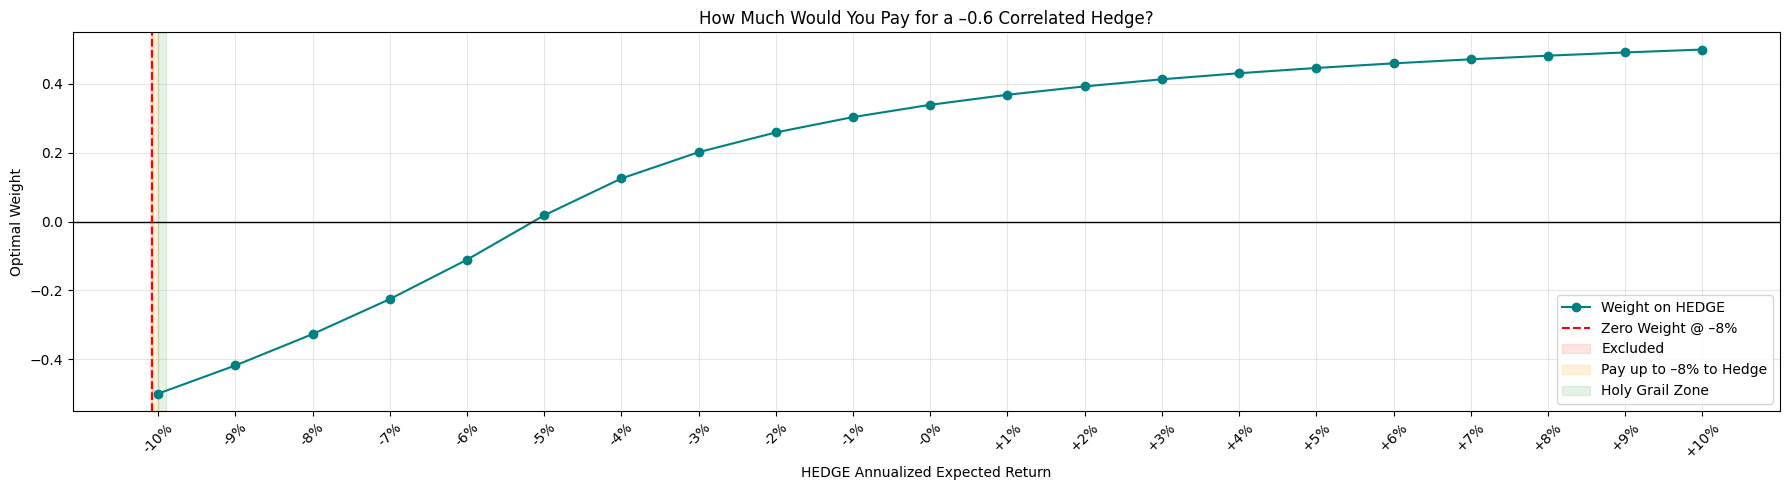

In [25]:
# --- Highlight the "pay to hedge" zone ---
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(wgts_df.index, wgts_df['HEDGE'], 'o-', color='teal', label='Weight on HEDGE', markersize=6)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(-0.08, color='red', linestyle='--', label='Zero Weight @ –8%')
ax.axvspan(-0.10, -0.08, color='red', alpha=0.1, label='Excluded')
ax.axvspan(-0.08, 0.0, color='orange', alpha=0.15, label='Pay up to –8% to Hedge')
ax.axvspan(0.0, 0.10, color='green', alpha=0.1, label='Holy Grail Zone')
ax.set_xlabel('HEDGE Annualized Expected Return')
ax.set_ylabel('Optimal Weight')
ax.set_title('How Much Would You Pay for a –0.6 Correlated Hedge?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Interpretation**:
> - **Red zone**: HEDGE is **excluded** — too costly.
> - **Orange zone**: You **pay to hedge** — negative return, but worth it.
> - **Green zone**: **Holy grail** — hedge **and** make money.

This is **mean-variance optimization telling you the fair price of risk reduction**.